# Gold ETF and Multi-Asset Price Forecasting — Exploratory Data Analysis

This notebook performs a comprehensive exploratory data analysis on the GLD Gold ETF
alongside a curated set of related ETFs and equities. The goal is to understand price
behaviour, volume patterns, volatility regimes, and inter-asset relationships before
moving into machine learning and deep learning modelling stages.

**Dataset:** Stock Market Dataset (Kaggle)  
**Primary Target Asset:** GLD — SPDR Gold Shares ETF  
**Supporting Assets:** SLV, SPY, UUP, gold mining stocks, volatility ETFs, and more


## 1. Library Imports

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import dask.dataframe as dd
import pandas as pd
import kagglehub
import numpy as np
import os

# Create a dedicated folder to store all exported plot images
# This makes it easy to embed charts in reports or README files later
os.makedirs("plots", exist_ok=True)

# Apply a clean visual style across all plots for a consistent, professional look
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


## 2. Loading the Raw Data

In [ ]:
kagglehub.dataset_download("jacksoncrow/stock-market-dataset")


stocks_data = dd.read_csv(
    "/kaggle/input/stock-market-dataset/stocks/*.csv",
    include_path_column="File_Path",
    dtype={
        "Volume": "float64"
    }
)

etfs_data = dd.read_csv(
    "/kaggle/input/stock-market-dataset/etfs/*.csv",
    include_path_column="File_Path",
    dtype={
        "Volume": "float64"
    }
)

symbols_valid_meta_data = dd.read_csv(
    "/kaggle/input/stock-market-dataset/symbols_valid_meta.csv"
)


Using Colab cache for faster access to the 'stock-market-dataset' dataset.


## 3. Extracting Ticker Symbols from File Paths

In [ ]:
# Each file in the dataset is named after its ticker symbol (e.g. GLD.csv)
# We extract that ticker from the file path and store it as its own column
# This makes filtering and grouping by asset much simpler downstream
stocks_data["Ticker"] = (
    stocks_data["File_Path"]
    .str.split("/")
    .str[-1]
    .str.replace(".csv", "", regex=False)
)

etfs_data["Ticker"] = (
    etfs_data["File_Path"]
    .str.split("/")
    .str[-1]
    .str.replace(".csv", "", regex=False)
)


## 4. Initial Data Preview

In [ ]:
# A quick look at the first few rows to confirm the data loaded correctly
stocks_data.head()


,Date,Open,High,Low,Close,Adj Close,Volume,File_Path,Ticker
0,1999-11-18,32.546494,35.765381,28.612303,31.473534,27.068665,62546300.0,/kaggle/input/stock-market-dataset/stocks/A.csv,A
1,1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100.0,/kaggle/input/stock-market-dataset/stocks/A.csv,A
2,1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800.0,/kaggle/input/stock-market-dataset/stocks/A.csv,A
3,1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600.0,/kaggle/input/stock-market-dataset/stocks/A.csv,A
4,1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200.0,/kaggle/input/stock-market-dataset/stocks/A.csv,A


In [ ]:
# Listing all available columns so we know what fields to work with
stocks_data.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'File_Path', 'Ticker'],
      dtype='object')

In [ ]:
# Checking data types to spot any columns that may need type conversion later
stocks_data.dtypes


,0
Date,string[pyarrow]
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64
File_Path,category
Ticker,object


## 5. Selecting Assets of Interest

In [ ]:
BASE_PATH = "/kaggle/input/stock-market-dataset"

# These ETFs were selected to represent a broad macro picture around gold
# Gold and precious metals ETFs are our primary subject
# Market indices, dollar strength, commodities, and volatility instruments provide context
etf_tickers = [

    # Gold and precious metals — these are the core assets we are studying
    "GLD",   # SPDR Gold Shares — the main target
    "SLV",   # iShares Silver Trust — closely related precious metal
    "GDX",   # VanEck Gold Miners ETF — exposure to gold mining companies
    "GDXJ",  # VanEck Junior Gold Miners — smaller, higher-risk miners

    # Broad market indices — used to understand gold's relationship with equities
    "SPY",   # SPDR S&P 500 — the most widely tracked US equity benchmark
    "QQQ",   # Invesco Nasdaq 100 — technology-heavy index
    "DIA",   # SPDR Dow Jones Industrial Average ETF
    "IWM",   # iShares Russell 2000 — small-cap equities

    # Dollar strength and fixed income — key macro drivers for gold pricing
    "UUP",   # Invesco DB US Dollar Index Bullish Fund
    "TLT",   # iShares 20 Plus Year Treasury Bond ETF
    "TIP",   # iShares TIPS Bond ETF — inflation-protected securities

    # Commodities — to understand gold in a broader raw materials context
    "USO",   # United States Oil Fund
    "DBC",   # Invesco DB Commodity Index Tracking Fund

    # Volatility instruments — fear and uncertainty tend to drive gold demand
    "UVXY",  # ProShares Ultra VIX Short-Term Futures ETF
    "VIXY",  # ProShares VIX Short-Term Futures ETF

    # Financial sector — sensitive to interest rates which also affect gold
    "XLF",   # Financial Select Sector SPDR Fund

    # Emerging markets — another risk asset class that often moves with gold
    "EEM"    # iShares MSCI Emerging Markets ETF
]

# Individual gold mining stocks provide company-level insight alongside ETF-level data
stock_tickers = [

    # Major gold producers — their performance mirrors gold prices closely
    "GOLD",  # Barrick Gold Corporation
    "NEM",   # Newmont Corporation
    "AEM",   # Agnico Eagle Mines
    "FNV",   # Franco-Nevada Corporation — a royalty and streaming company
    "KGC",   # Kinross Gold Corporation

    # Major technology stocks — included to contrast gold with growth equities
    "AAPL",
    "MSFT",
    "NVDA",
    "TSLA"
]

# Load only the metadata columns we actually need
meta_df = pd.read_csv(f"{BASE_PATH}/symbols_valid_meta.csv")
meta_df = meta_df[["Symbol", "Security Name", "ETF"]]

# Read each ticker file individually and combine them into one master dataframe
# We tag each row with its ticker and whether it is an ETF or a stock
dfs = []
missing_files = []

for ticker in etf_tickers:
    file_path = f"{BASE_PATH}/etfs/{ticker}.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["Ticker"] = ticker
        df["Asset_Type"] = "ETF"
        dfs.append(df)
    else:
        missing_files.append(file_path)

for ticker in stock_tickers:
    file_path = f"{BASE_PATH}/stocks/{ticker}.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["Ticker"] = ticker
        df["Asset_Type"] = "Stock"
        dfs.append(df)
    else:
        missing_files.append(file_path)

# Merge all individual asset dataframes into a single consolidated dataframe
final_df = pd.concat(dfs, ignore_index=True)

# Attach security names and ETF flag from the metadata file
final_df = final_df.merge(
    meta_df,
    left_on="Ticker",
    right_on="Symbol",
    how="left"
)

print("Combined dataset shape:", final_df.shape)
if missing_files:
    print("Files not found:", missing_files)


Combined dataset shape: (139303, 12)


## 6. Exploratory Data Analysis

In [ ]:
# A high-level summary of the dataframe including column types and non-null counts
# This helps us spot any unexpected data type issues before we start computing
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139303 entries, 0 to 139302
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           139303 non-null  object 
 1   Open           139299 non-null  float64
 2   High           139299 non-null  float64
 3   Low            139299 non-null  float64
 4   Close          139299 non-null  float64
 5   Adj Close      139299 non-null  float64
 6   Volume         139299 non-null  float64
 7   Ticker         139303 non-null  object 
 8   Asset_Type     139303 non-null  object 
 9   Symbol         139303 non-null  object 
 10  Security Name  139303 non-null  object 
 11  ETF            139303 non-null  object 
dtypes: float64(6), object(6)
memory usage: 12.8+ MB


In [ ]:
# Sort by ticker and date so that time-based calculations like rolling windows
# are computed in the correct chronological order within each asset
final_df = final_df.sort_values(["Ticker", "Date"])
final_df["Date"] = pd.to_datetime(final_df["Date"])
final_df.reset_index(drop=True, inplace=True)

# Identify any missing values across all columns
missing_values = final_df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])


Missing values per column:
Open         4
High         4
Low          4
Close        4
Adj Close    4
Volume       4
dtype: int64


In [ ]:
# We drop rows with missing values rather than imputing them
# For financial price data, filling missing prices with an average would introduce
# artificial values that could mislead the model — so removal is the safer choice
final_df = final_df.dropna().reset_index(drop=True)

# Extract all GLD rows into a dedicated dataframe for focused gold analysis
gld_df = final_df[final_df["Ticker"] == "GLD"].copy()

# Compute the daily return for GLD — this is the percentage change in closing price
# It is a fundamental feature for volatility and regime analysis
gld_df["Daily_Return"] = gld_df["Close"].pct_change()

print("GLD dataset shape:", gld_df.shape)
gld_df.describe()


GLD dataset shape: (3868, 13)


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return
count,3868,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3.868000e+03,3867.000000
mean,2012-07-25 16:59:19.048603904,110.140215,110.700372,109.534767,110.135884,110.135884,9.731130e+06,0.000380
min,2004-11-18 00:00:00,41.029999,41.360001,41.020000,41.259998,41.259998,3.193000e+05,-0.087808
25%,2008-09-22 18:00:00,88.325001,89.367502,87.507498,88.327501,88.327501,5.118025e+06,-0.005217
50%,2012-07-24 12:00:00,117.529999,117.980000,116.980003,117.535000,117.535000,7.999750e+06,0.000554
75%,2016-05-28 00:00:00,128.064999,128.627495,127.570000,127.985001,127.985001,1.210288e+07,0.006183
max,2020-04-01 00:00:00,184.580002,185.850006,182.100006,184.589996,184.589996,9.380420e+07,0.112905
std,NaN,33.547548,33.663945,33.406744,33.540022,33.540022,7.237710e+06,0.011505


## 7. Gold ETF Price Trend Over Time

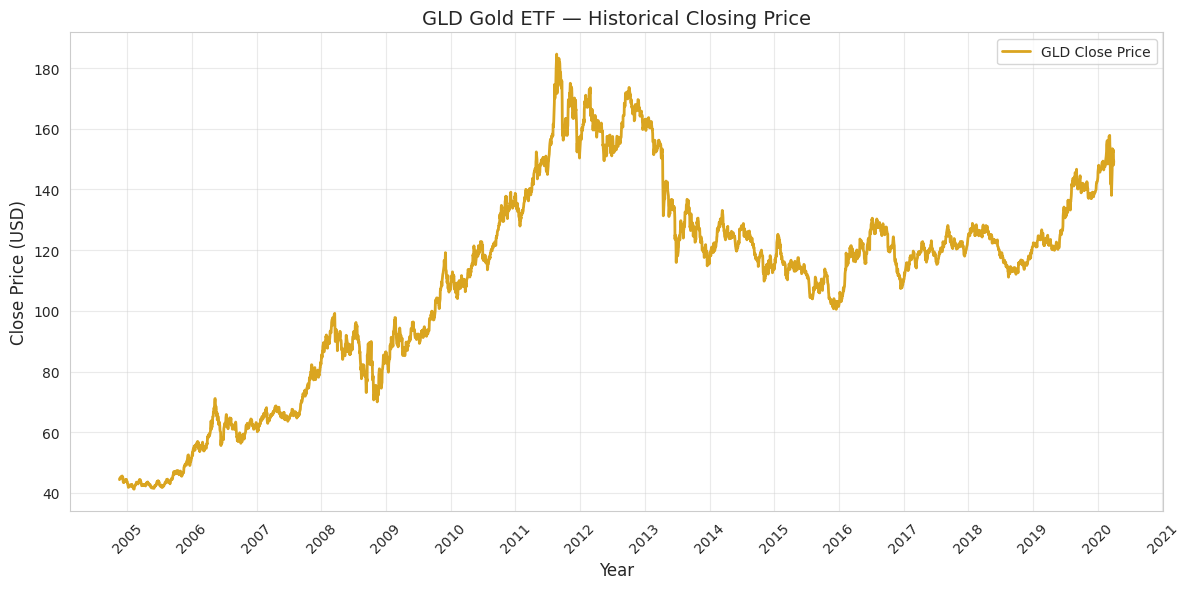

In [ ]:
# This chart shows the full historical closing price of GLD from the start of our data
# Rising trends indicate increased demand for gold, often driven by inflation fears,
# market uncertainty, or dollar weakness
plt.figure(figsize=(12, 6))

plt.plot(
    gld_df["Date"],
    gld_df["Close"],
    linewidth=2,
    label="GLD Close Price",
    color="goldenrod"
)

plt.title("GLD Gold ETF — Historical Closing Price")
plt.xlabel("Year")
plt.ylabel("Close Price (USD)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("plots/01_gld_price_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. 30-Day Average Trading Volume

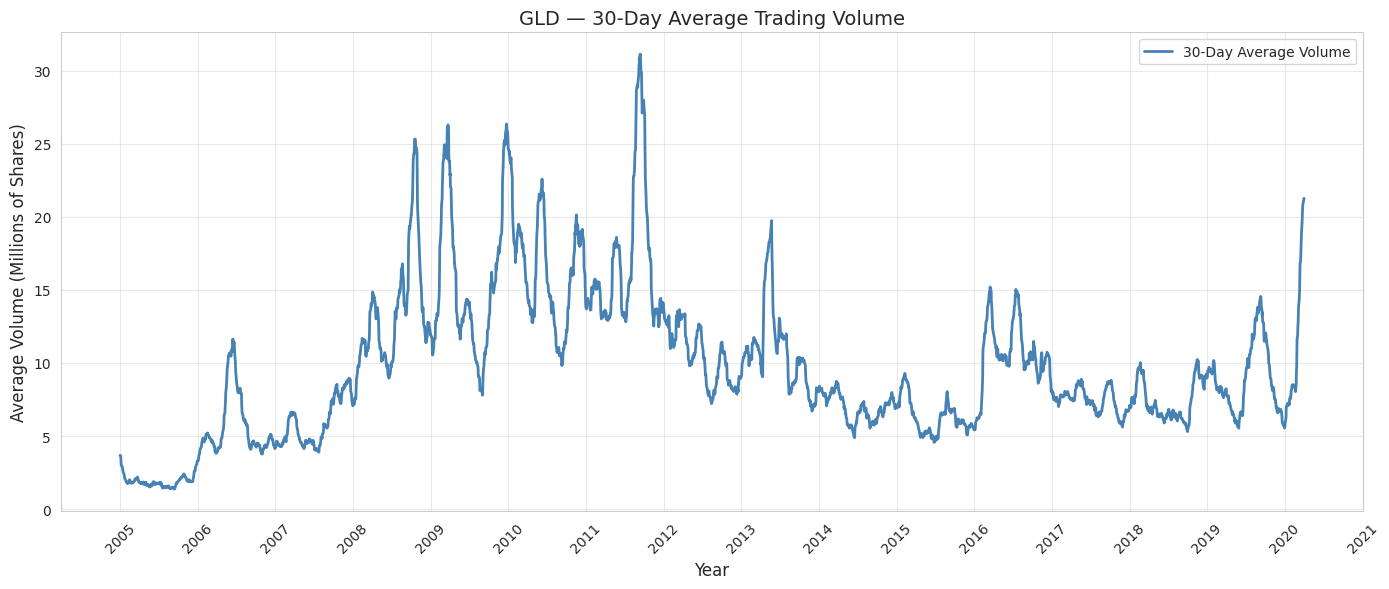

In [ ]:
# A 30-day rolling average smooths out day-to-day noise in trading volume
# Spikes in average volume often coincide with major market events or price breakouts
# Expressed in millions of shares for readability
gld_df["Volume_MA30"] = gld_df["Volume"].rolling(30).mean()
gld_df["Volume_MA30_Millions"] = gld_df["Volume_MA30"] / 1_000_000

plt.figure(figsize=(14, 6))

plt.plot(
    gld_df["Date"],
    gld_df["Volume_MA30_Millions"],
    linewidth=2,
    label="30-Day Average Volume",
    color="steelblue"
)

plt.title("GLD — 30-Day Average Trading Volume")
plt.xlabel("Year")
plt.ylabel("Average Volume (Millions of Shares)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("plots/02_gld_volume_ma30.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Daily Return Distribution

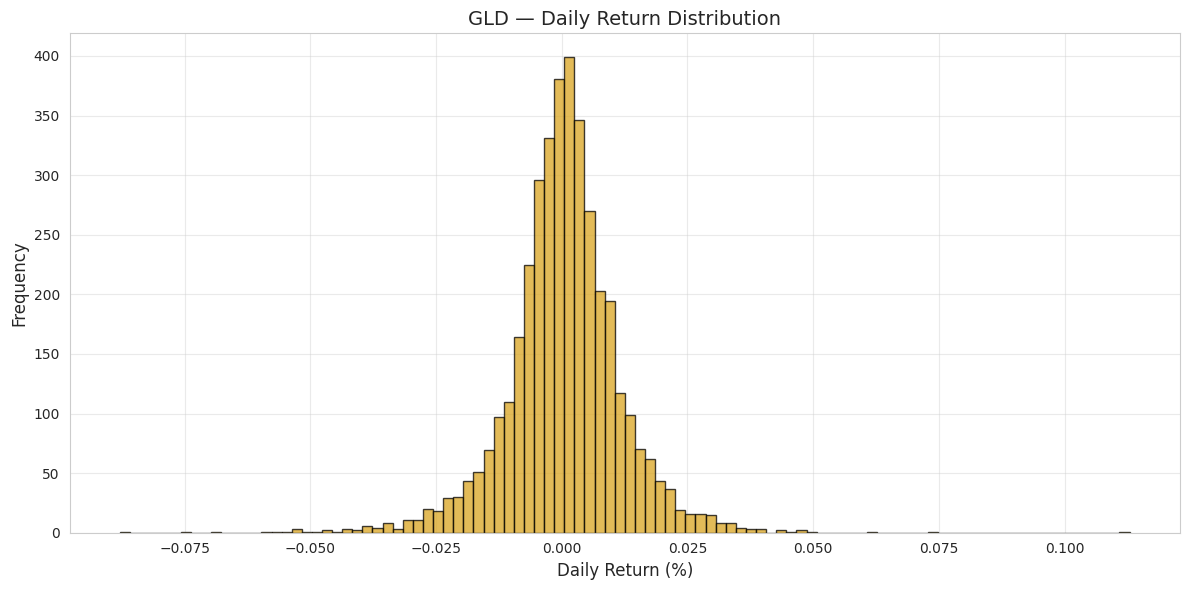

In [ ]:
# The distribution of daily returns tells us how often large gains or losses occur
# A normal bell curve would suggest predictable behaviour
# A heavy-tailed or skewed distribution is common in financial assets and signals
# that extreme events happen more often than a normal model would predict
plt.figure(figsize=(12, 6))

plt.hist(
    gld_df["Daily_Return"].dropna(),
    bins=100,
    alpha=0.75,
    edgecolor="black",
    color="goldenrod"
)

plt.title("GLD — Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.savefig("plots/03_gld_daily_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Moving Averages — Trend Identification

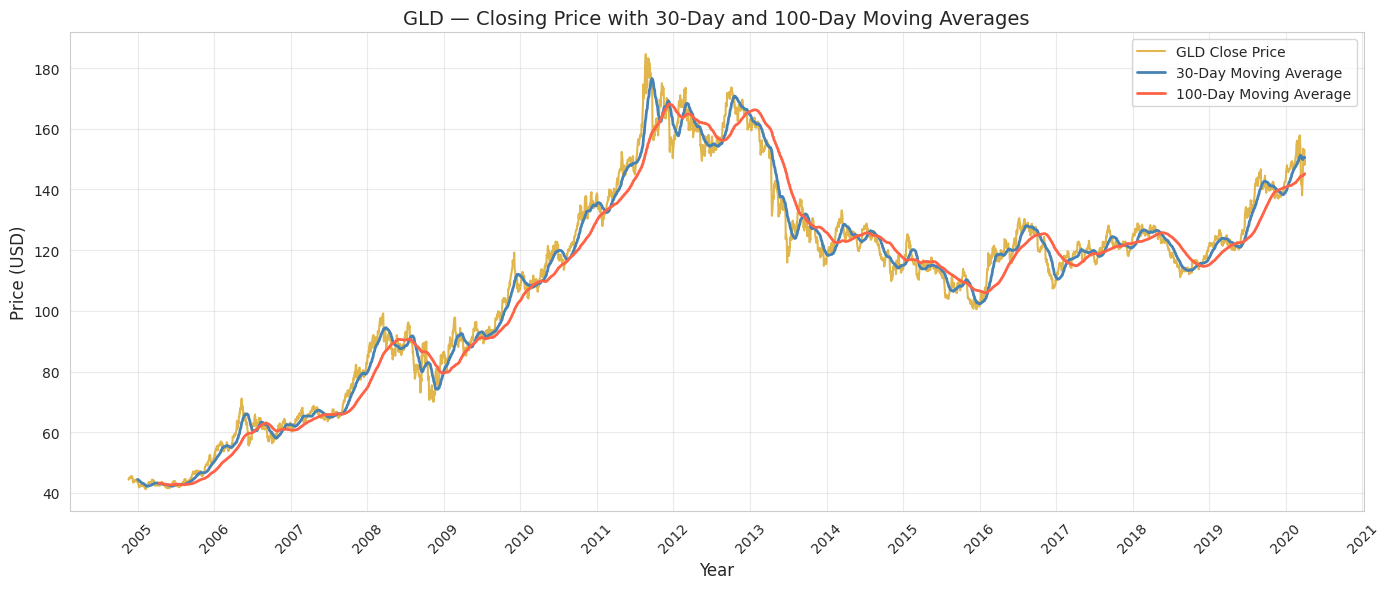

In [ ]:
# Moving averages are one of the most widely used tools in technical analysis
# The 30-day MA captures short-term momentum while the 100-day MA reflects the longer trend
# When the short-term average crosses above the long-term, it is often interpreted
# as a bullish signal (golden cross), and vice versa for a bearish signal (death cross)
gld_df["MA_30"] = gld_df["Close"].rolling(30).mean()
gld_df["MA_100"] = gld_df["Close"].rolling(100).mean()

plt.figure(figsize=(14, 6))

plt.plot(gld_df["Date"], gld_df["Close"],
         label="GLD Close Price", linewidth=1.5, alpha=0.8, color="goldenrod")

plt.plot(gld_df["Date"], gld_df["MA_30"],
         label="30-Day Moving Average", linewidth=2, color="steelblue")

plt.plot(gld_df["Date"], gld_df["MA_100"],
         label="100-Day Moving Average", linewidth=2, color="tomato")

plt.title("GLD — Closing Price with 30-Day and 100-Day Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("plots/04_gld_moving_averages.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. 30-Day Rolling Volatility

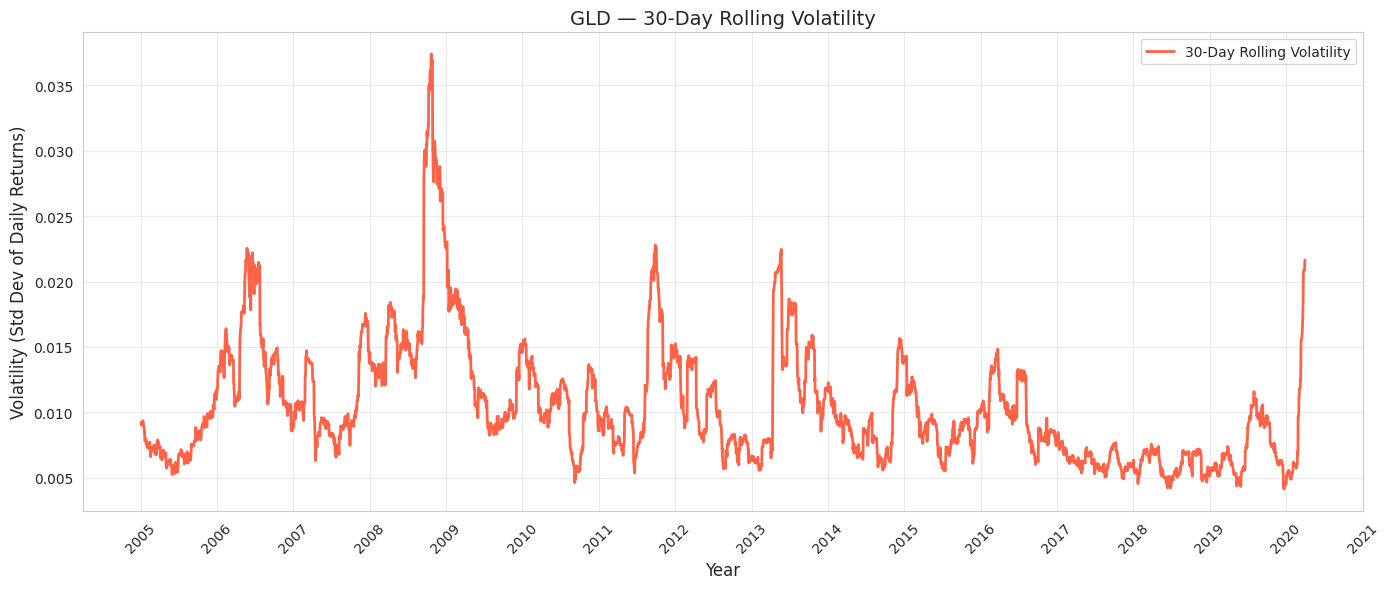

In [ ]:
# Rolling volatility measures how much the daily return fluctuates over a 30-day window
# High volatility periods correspond to market stress, uncertainty, or major news events
# This feature will be important for the machine learning model as gold often spikes
# in volatility during economic crises or geopolitical events
gld_df["Volatility_30"] = gld_df["Daily_Return"].rolling(30).std()

plt.figure(figsize=(14, 6))

plt.plot(
    gld_df["Date"],
    gld_df["Volatility_30"],
    linewidth=2,
    label="30-Day Rolling Volatility",
    color="tomato"
)

plt.title("GLD — 30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility (Std Dev of Daily Returns)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("plots/05_gld_rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Multi-Asset Price Comparison

/tmp/ipykernel_6443/4003426810.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  wide_returns = wide_close.pct_change()


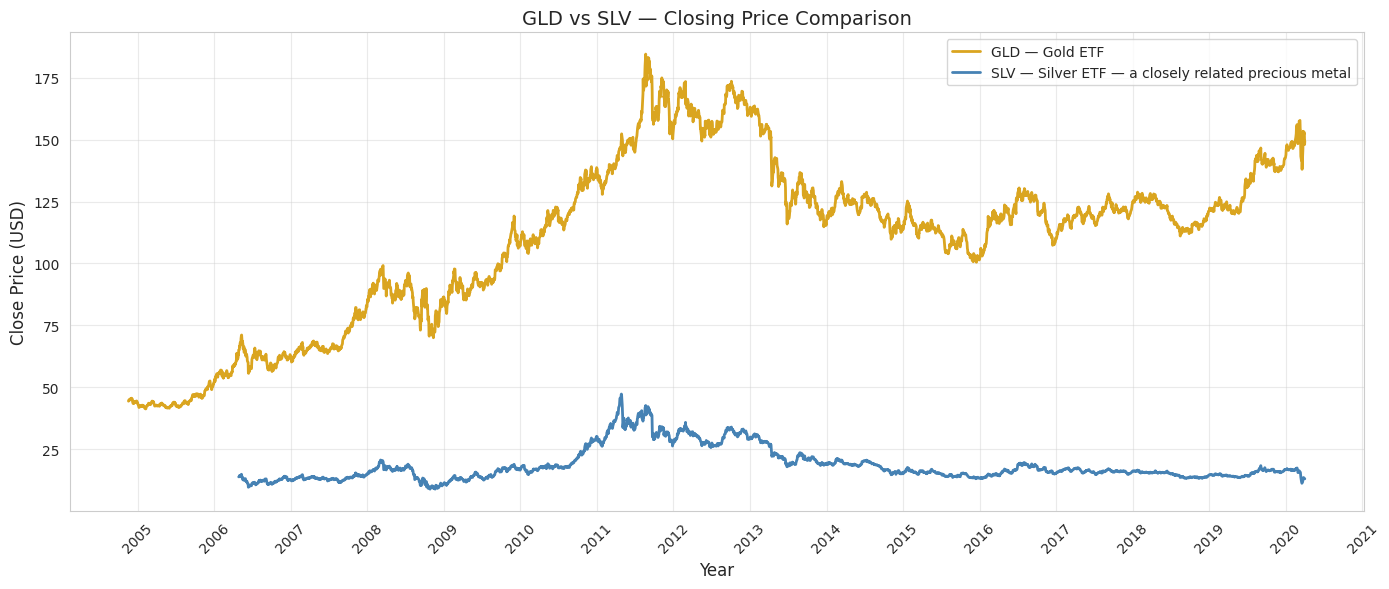

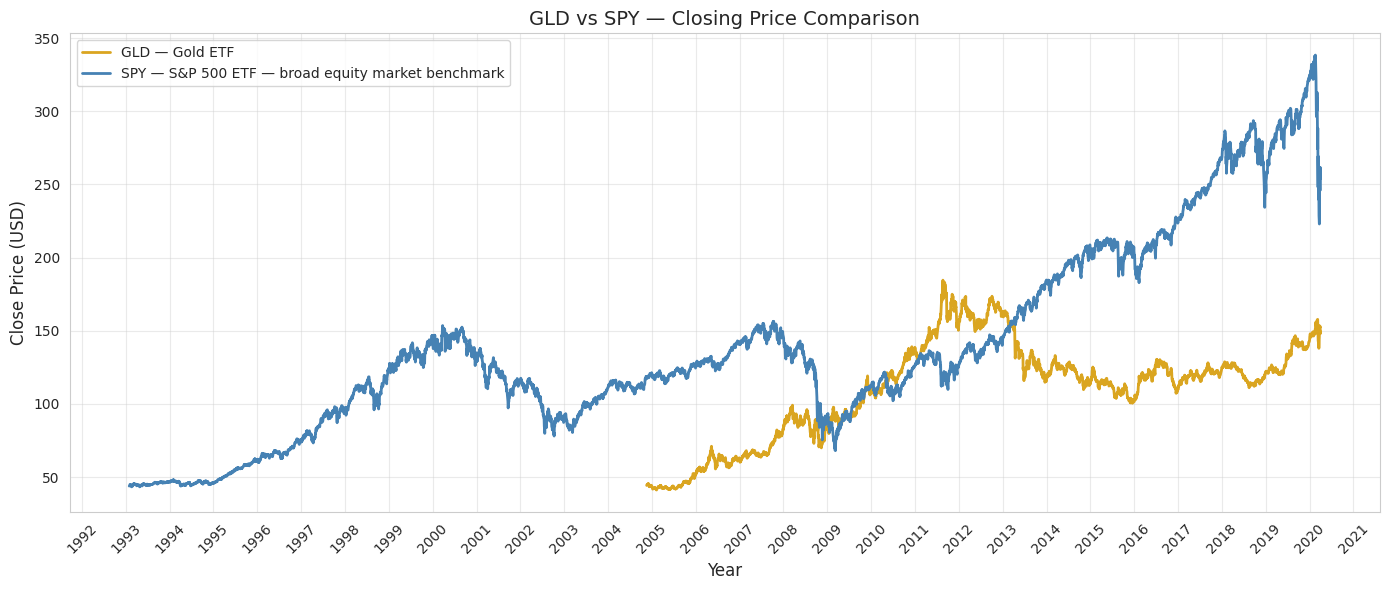

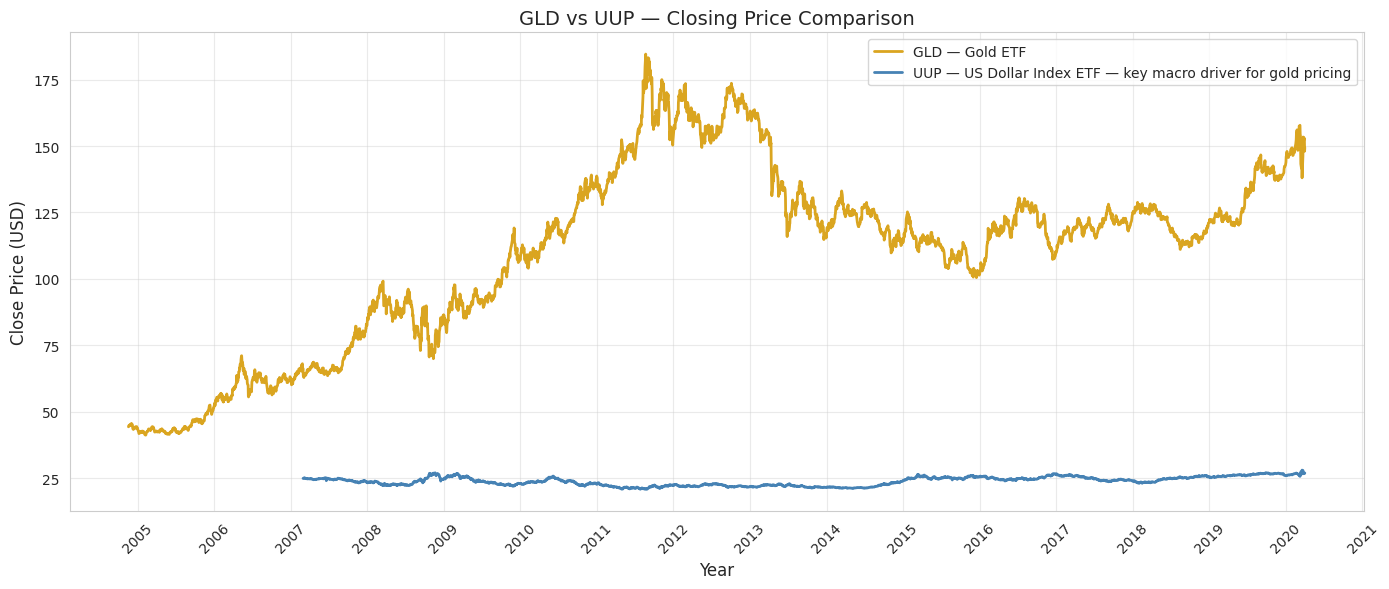

In [ ]:
# Build a wide-format table where each column is an asset and each row is a date
# This makes it straightforward to compare prices across multiple assets on the same chart
wide_close = final_df.pivot(index="Date", columns="Ticker", values="Close")
wide_returns = wide_close.pct_change()

# We compare GLD against three key assets that represent different macro forces
# SLV: closely correlated with gold as another precious metal
# SPY: the broad equity market — gold often moves inversely during risk-off periods
# UUP: the US dollar index — gold is priced in dollars so they tend to move inversely
comparison_assets = ["SLV", "SPY", "UUP"]

asset_labels = {
    "SLV": "Silver ETF — a closely related precious metal",
    "SPY": "S&P 500 ETF — broad equity market benchmark",
    "UUP": "US Dollar Index ETF — key macro driver for gold pricing"
}

for i, asset in enumerate(comparison_assets, start=1):
    if asset in wide_close.columns:

        plt.figure(figsize=(14, 6))

        plt.plot(wide_close.index, wide_close["GLD"],
                 label="GLD — Gold ETF", linewidth=2, color="goldenrod")

        plt.plot(wide_close.index, wide_close[asset],
                 label=f"{asset} — {asset_labels.get(asset, asset)}", linewidth=2, color="steelblue")

        plt.title(f"GLD vs {asset} — Closing Price Comparison")
        plt.xlabel("Year")
        plt.ylabel("Close Price (USD)")

        plt.gca().xaxis.set_major_locator(mdates.YearLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.4)
        plt.legend()
        plt.tight_layout()

        plt.savefig(f"plots/06_{i}_gld_vs_{asset.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()


## 13. Correlation Heatmap — Daily Returns Across Assets

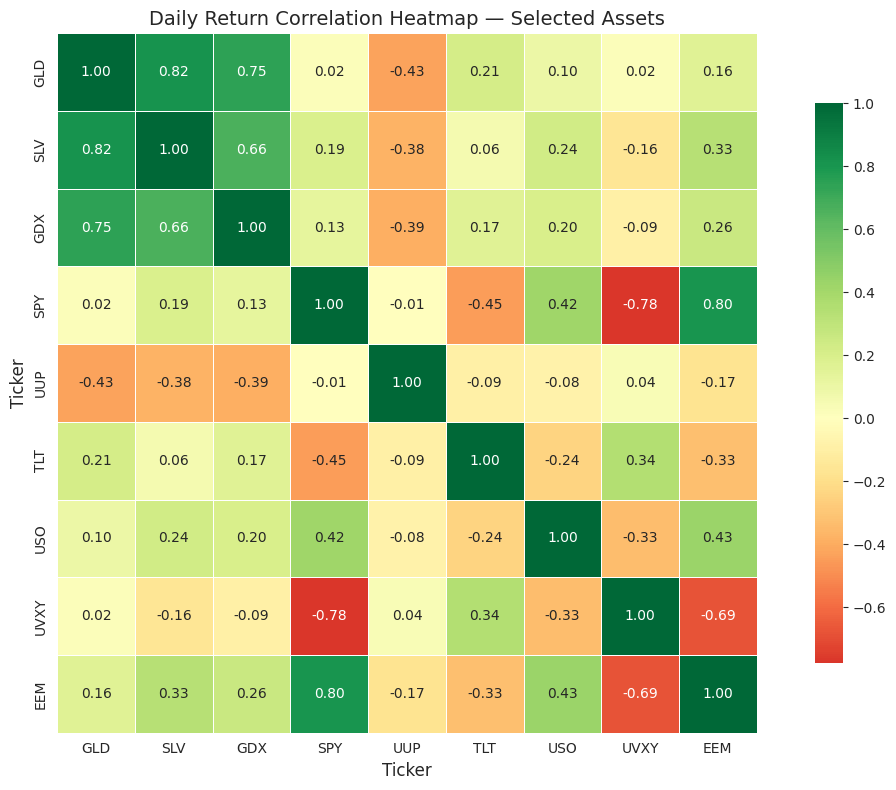

In [ ]:
# Understanding how assets move together is critical for feature selection
# Assets with high positive correlation to GLD will make strong predictive features
# Assets with negative or near-zero correlation are useful for capturing divergence signals
# We compute correlations on daily returns rather than raw prices to avoid spurious trends

selected_tickers = ["GLD", "SLV", "GDX", "SPY", "UUP", "TLT", "USO", "UVXY", "EEM"]
corr_df = wide_returns[selected_tickers].dropna()
correlation_matrix = corr_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Daily Return Correlation Heatmap — Selected Assets")
plt.tight_layout()

plt.savefig("plots/07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Market Regime Analysis — KMeans Clustering

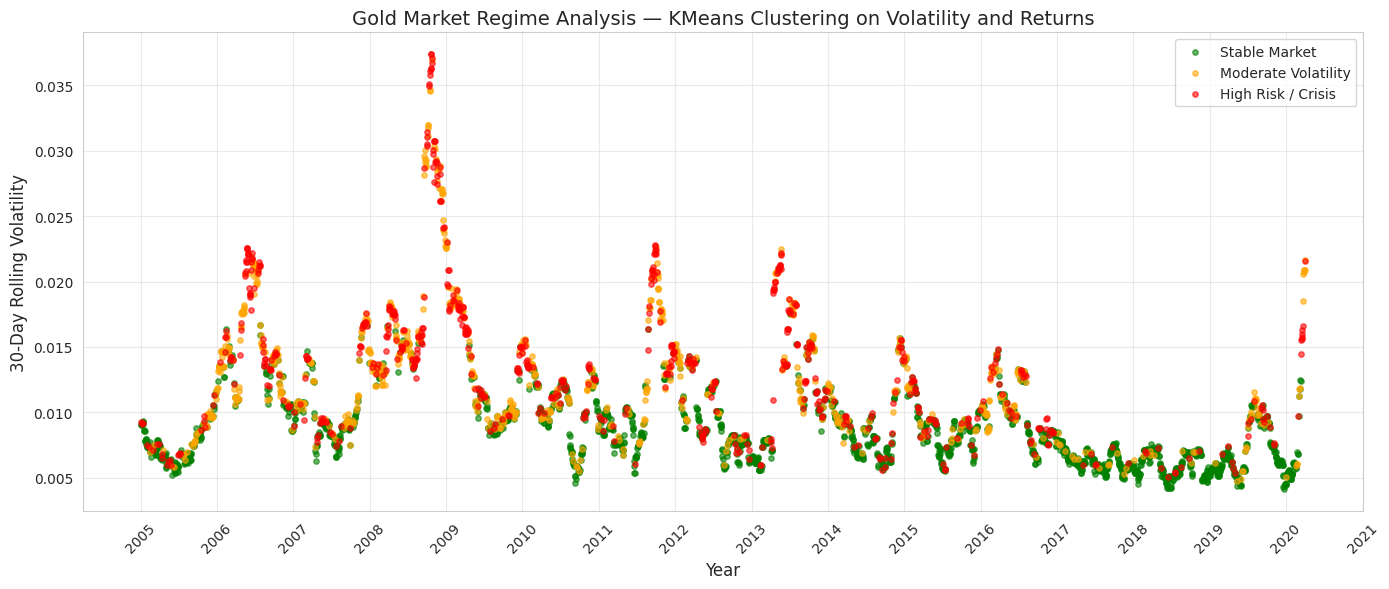

Regime distribution:
Regime_Label
Stable Market          2344
Moderate Volatility     844
High Risk / Crisis      650
Name: count, dtype: int64


In [ ]:
# Market regimes describe the different states a market can be in
# For example, a calm trending market behaves very differently from a crisis period
# We use KMeans clustering to automatically discover three distinct regimes from the data
# The features used are daily return, 7-day return, rolling volatility, and volume change
# These together capture both the direction and intensity of market behaviour

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Build the 7-day return and volume change features
gld_df["Return_7D"] = gld_df["Close"].pct_change(7)
gld_df["Volume_Change"] = gld_df["Volume"].pct_change()

regime_df = gld_df[[
    "Daily_Return",
    "Return_7D",
    "Volatility_30",
    "Volume_Change"
]].dropna().copy()

# Scale all features to the same range so that no single variable dominates the clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(regime_df)

# Fit KMeans with three clusters — stable, moderate, and high-risk regimes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
regime_df["Regime"] = kmeans.fit_predict(scaled_data)

# Sort clusters by average volatility to assign interpretable human-readable labels
regime_summary = regime_df.groupby("Regime")["Volatility_30"].mean().sort_values()

label_map = {
    regime_summary.index[0]: "Stable Market",
    regime_summary.index[1]: "Moderate Volatility",
    regime_summary.index[2]: "High Risk / Crisis"
}

regime_df["Regime_Label"] = regime_df["Regime"].map(label_map)

regime_colours = {
    "Stable Market": "green",
    "Moderate Volatility": "orange",
    "High Risk / Crisis": "red"
}

plt.figure(figsize=(14, 6))

for label in ["Stable Market", "Moderate Volatility", "High Risk / Crisis"]:
    temp = regime_df[regime_df["Regime_Label"] == label]
    plt.scatter(
        gld_df.loc[temp.index, "Date"],
        temp["Volatility_30"],
        label=label,
        alpha=0.6,
        s=15,
        color=regime_colours[label]
    )

plt.title("Gold Market Regime Analysis — KMeans Clustering on Volatility and Returns")
plt.xlabel("Year")
plt.ylabel("30-Day Rolling Volatility")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("plots/08_market_regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Print a summary of how many days fall into each regime
print("Regime distribution:")
print(regime_df["Regime_Label"].value_counts())


## 16. Price Chart with Major Market Event Annotations

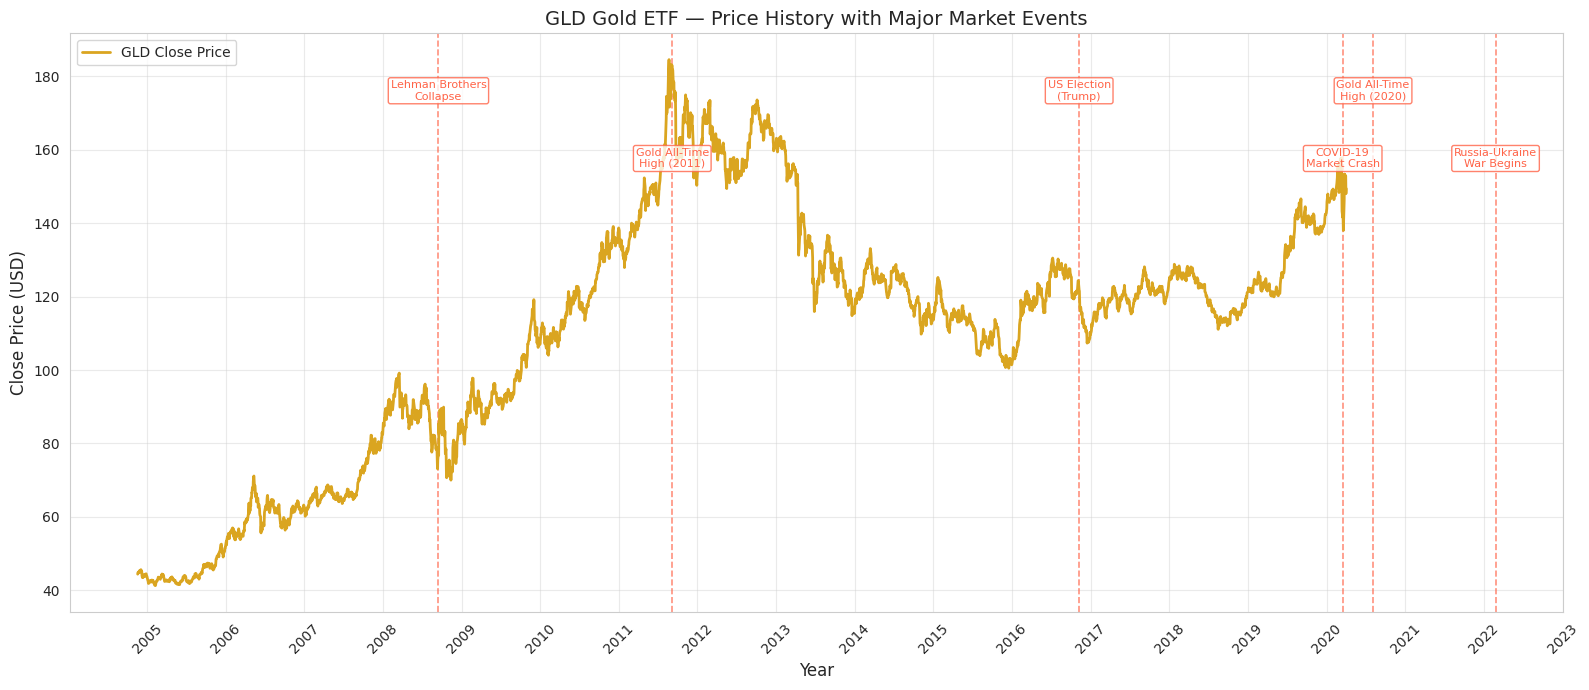

In [ ]:
# Annotating known historical events directly on the price chart adds real storytelling value
# It helps anyone reading the notebook understand what drove the major price movements
# Events like the 2008 financial crisis and the COVID-19 pandemic caused significant gold surges
# because investors moved money into safe-haven assets during uncertainty

major_events = [
    ("2008-09-15", "Lehman Brothers\nCollapse"),
    ("2011-09-06", "Gold All-Time\nHigh (2011)"),
    ("2016-11-08", "US Election\n(Trump)"),
    ("2020-03-16", "COVID-19\nMarket Crash"),
    ("2020-08-04", "Gold All-Time\nHigh (2020)"),
    ("2022-02-24", "Russia-Ukraine\nWar Begins"),
]

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    gld_df["Date"],
    gld_df["Close"],
    linewidth=2,
    color="goldenrod",
    label="GLD Close Price",
    zorder=2
)

# Draw a vertical dashed line and label for each major event
# Labels alternate above and below the line so they do not overlap each other
for i, (date_str, label) in enumerate(major_events):
    event_date = pd.to_datetime(date_str)
    ax.axvline(
        x=event_date,
        color="tomato",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        zorder=1
    )
    y_pos = gld_df["Close"].max() * (0.97 if i % 2 == 0 else 0.87)
    ax.text(
        event_date,
        y_pos,
        label,
        fontsize=8,
        ha="center",
        va="top",
        color="tomato",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="tomato", alpha=0.8)
    )

ax.set_title("GLD Gold ETF — Price History with Major Market Events")
ax.set_xlabel("Year")
ax.set_ylabel("Close Price (USD)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()

plt.savefig("plots/09_gld_price_with_events.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Autocorrelation and Partial Autocorrelation — ACF and PACF

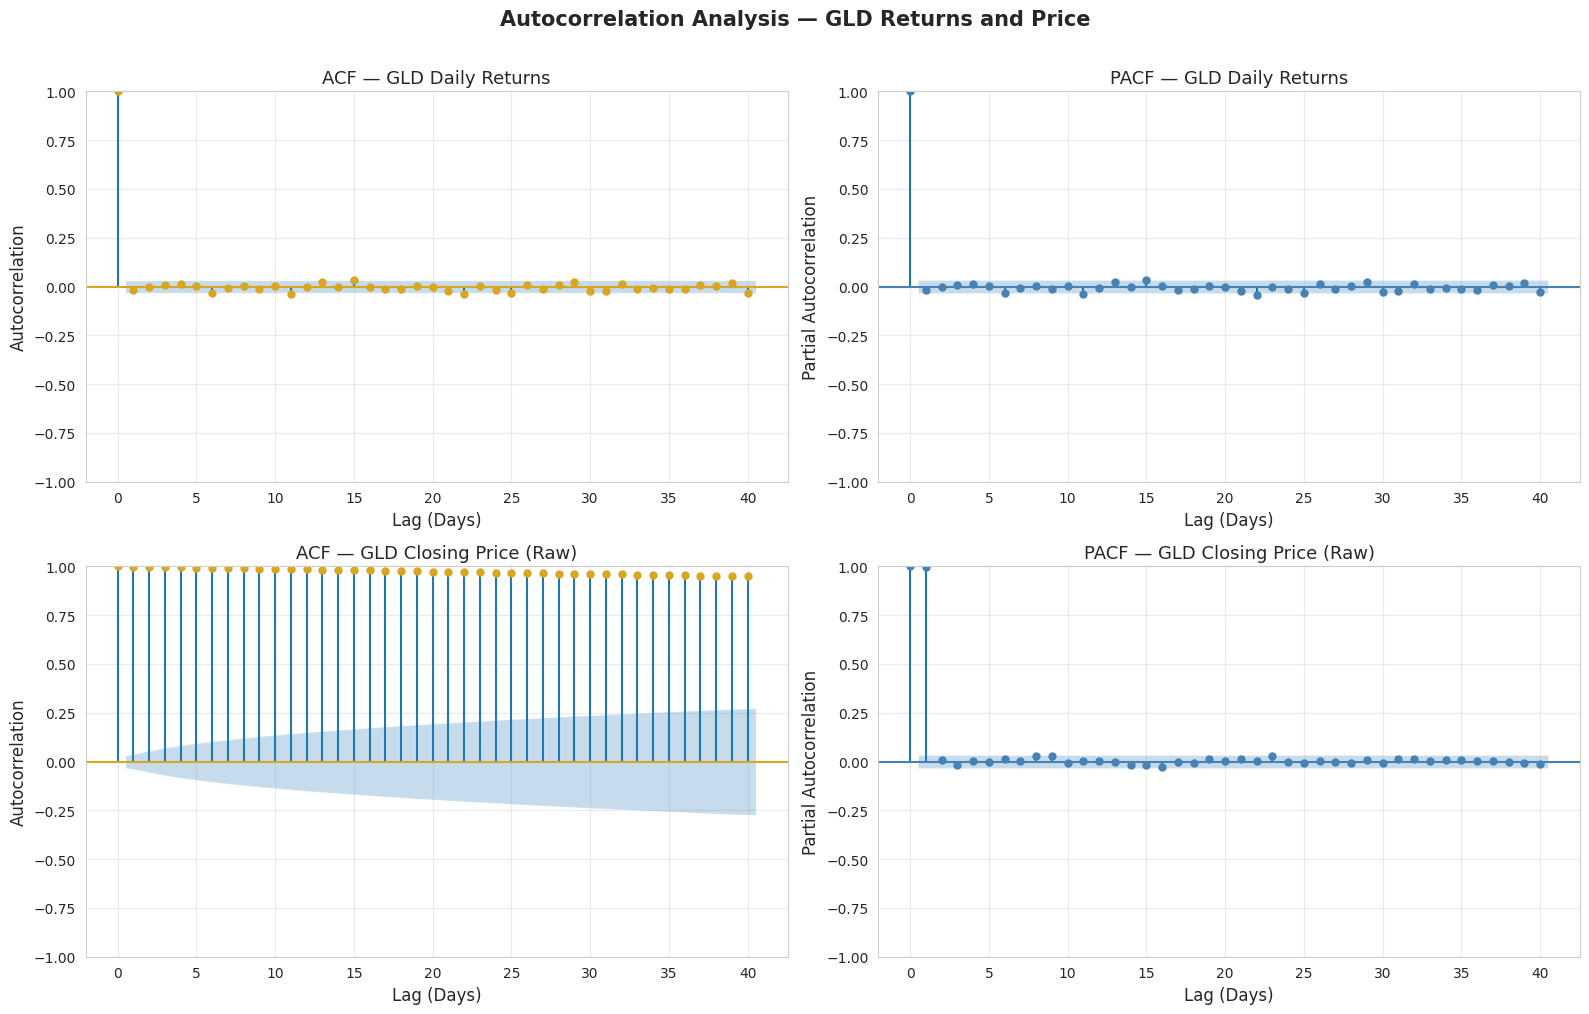

Stationarity Test — ADF on Daily Returns
  ADF Statistic : -63.1900
  p-value       : 0.000000
  Conclusion    : Stationary — safe to model directly

Stationarity Test — ADF on Raw Closing Price
  ADF Statistic : -1.7043
  p-value       : 0.428889
  Conclusion    : Non-stationary — differencing required


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# The ACF plot shows how strongly the current return is correlated with its own past values
# at each lag. For example, lag 1 tells us if today's return predicts tomorrow's return.
# The PACF shows the same but removes the indirect correlations from intermediate lags.
# These plots are essential for understanding memory in the time series and
# for choosing the right parameters for ARIMA-type models or deciding how many
# lag features to engineer for machine learning models.

daily_returns = gld_df["Daily_Return"].dropna()
close_prices  = gld_df["Close"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF of daily returns
plot_acf(daily_returns, lags=40, ax=axes[0, 0], color="goldenrod", title="")
axes[0, 0].set_title("ACF — GLD Daily Returns", fontsize=13)
axes[0, 0].set_xlabel("Lag (Days)")
axes[0, 0].set_ylabel("Autocorrelation")
axes[0, 0].grid(True, alpha=0.4)

# PACF of daily returns
plot_pacf(daily_returns, lags=40, ax=axes[0, 1], method="ywm", color="steelblue", title="")
axes[0, 1].set_title("PACF — GLD Daily Returns", fontsize=13)
axes[0, 1].set_xlabel("Lag (Days)")
axes[0, 1].set_ylabel("Partial Autocorrelation")
axes[0, 1].grid(True, alpha=0.4)

# ACF of closing price — raw prices are usually non-stationary and show strong autocorrelation
# across all lags, which is expected and confirms we need to work with returns for modelling
plot_acf(close_prices, lags=40, ax=axes[1, 0], color="goldenrod", title="")
axes[1, 0].set_title("ACF — GLD Closing Price (Raw)", fontsize=13)
axes[1, 0].set_xlabel("Lag (Days)")
axes[1, 0].set_ylabel("Autocorrelation")
axes[1, 0].grid(True, alpha=0.4)

# PACF of closing price
plot_pacf(close_prices, lags=40, ax=axes[1, 1], method="ywm", color="steelblue", title="")
axes[1, 1].set_title("PACF — GLD Closing Price (Raw)", fontsize=13)
axes[1, 1].set_xlabel("Lag (Days)")
axes[1, 1].set_ylabel("Partial Autocorrelation")
axes[1, 1].grid(True, alpha=0.4)

plt.suptitle("Autocorrelation Analysis — GLD Returns and Price", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig("plots/10_acf_pacf_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Augmented Dickey-Fuller test checks whether the series has a unit root
# A p-value below 0.05 means the series is stationary — safe to model directly
# A high p-value means it is non-stationary and needs differencing first
print("Stationarity Test — ADF on Daily Returns")
adf_result = adfuller(daily_returns)
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.6f}")
print(f"  Conclusion    : {'Stationary — safe to model directly' if adf_result[1] < 0.05 else 'Non-stationary — differencing required'}")

print()
print("Stationarity Test — ADF on Raw Closing Price")
adf_price = adfuller(close_prices.dropna())
print(f"  ADF Statistic : {adf_price[0]:.4f}")
print(f"  p-value       : {adf_price[1]:.6f}")
print(f"  Conclusion    : {'Stationary — safe to model directly' if adf_price[1] < 0.05 else 'Non-stationary — differencing required'}")


## 18. Seasonal Decomposition — Trend, Seasonality, and Residuals

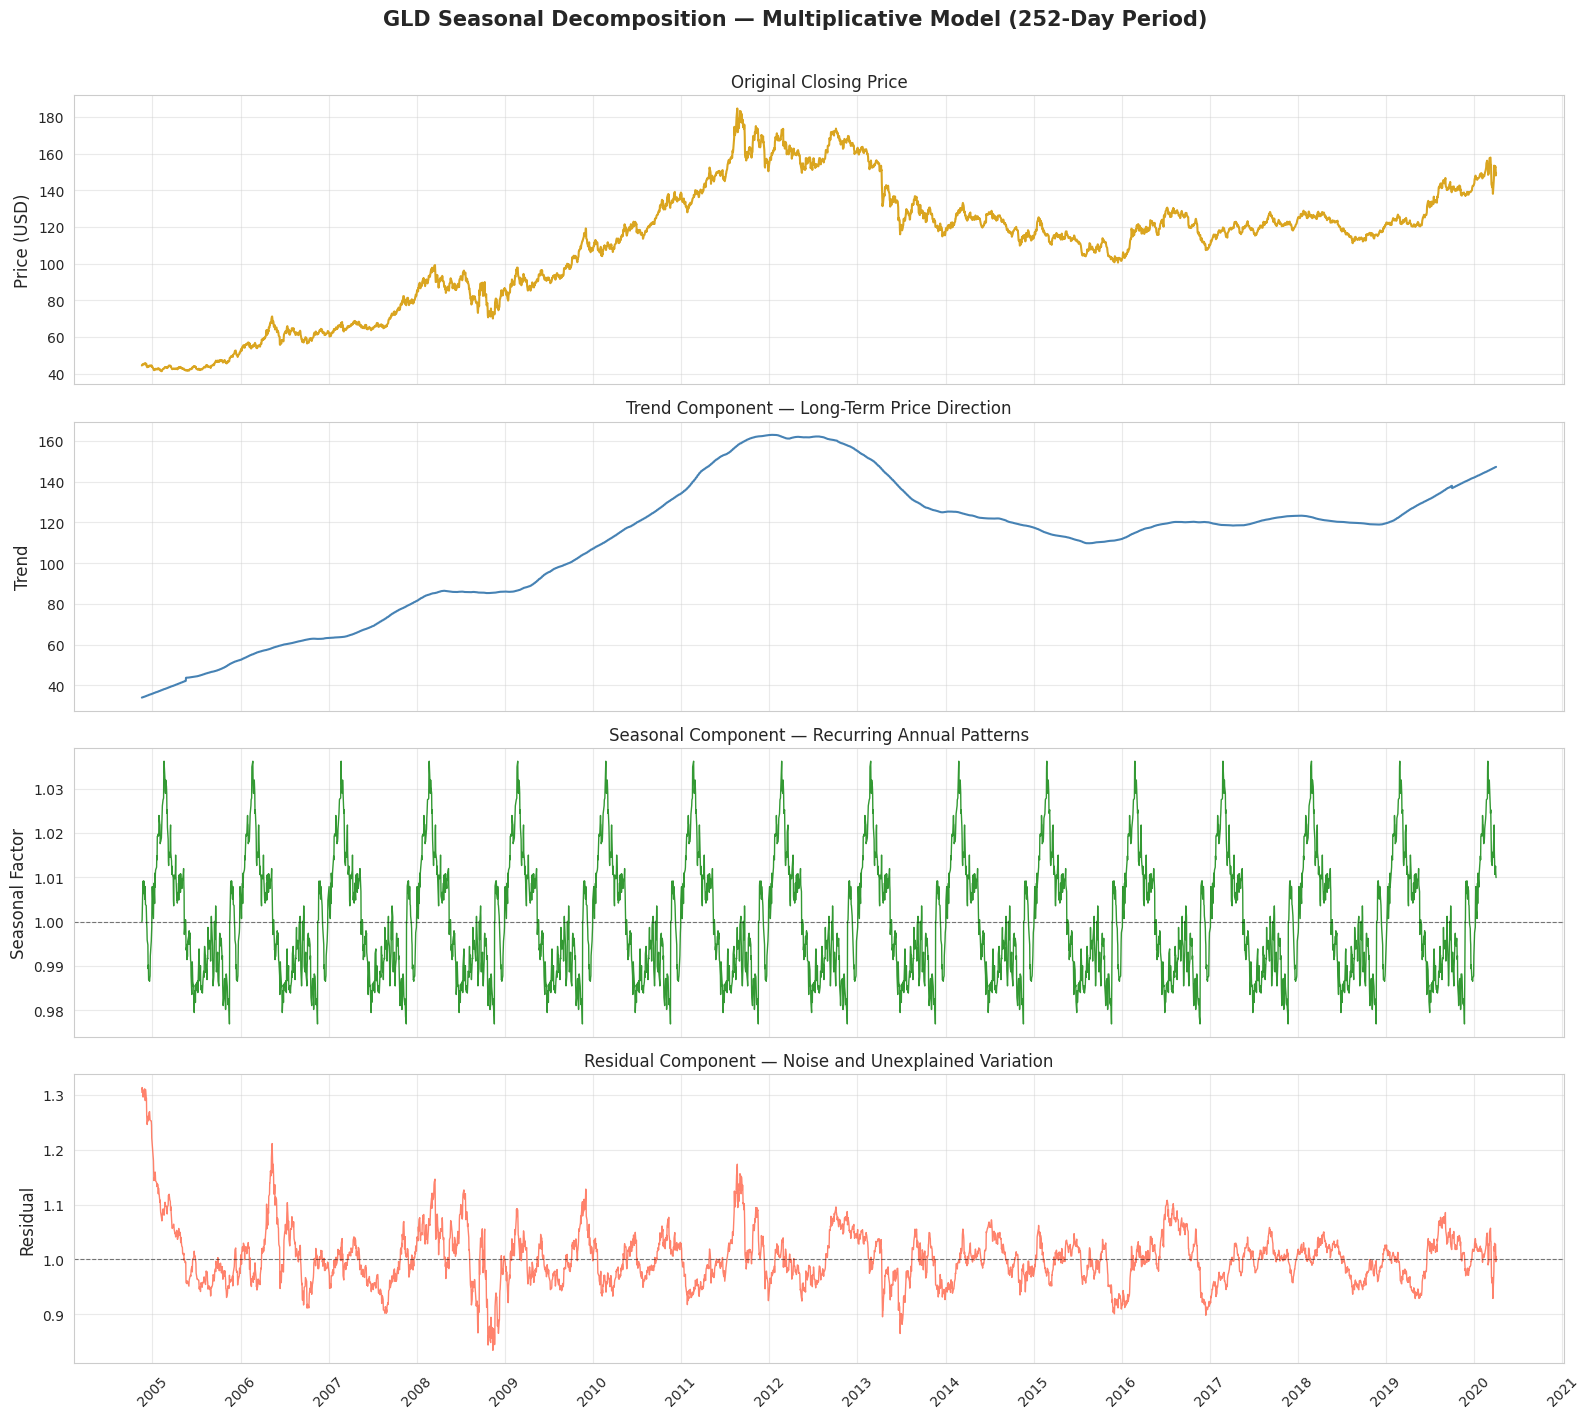

Decomposition Component Summary
  Trend relative strength   : 0.9846  (higher means trend dominates)
  Seasonal std deviation    : 0.0135  (lower means weak seasonality)
  Residual std deviation    : 0.0522  (lower means cleaner decomposition)


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition breaks the price series into three components:
#   Trend     — the long-term direction of the price, ignoring short-term noise
#   Seasonal  — repeating patterns that occur at regular intervals (weekly, monthly, annual)
#   Residual  — what is left after trend and seasonality are removed, often called noise
#
# For gold, we typically expect a strong trend component and weaker seasonality
# Any residual structure that remains may indicate useful signals for the model
#
# We use a 252-period window which corresponds roughly to one trading year
# This is the standard choice for annual seasonality in daily financial data

gld_close_indexed = gld_df.set_index("Date")["Close"]

decomposition = seasonal_decompose(
    gld_close_indexed,
    model="multiplicative",
    period=252,
    extrapolate_trend="freq"
)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Original price series
axes[0].plot(gld_close_indexed.index, gld_close_indexed.values,
             color="goldenrod", linewidth=1.5)
axes[0].set_title("Original Closing Price", fontsize=12)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.4)

# Trend component — the smooth underlying direction
axes[1].plot(gld_close_indexed.index, decomposition.trend,
             color="steelblue", linewidth=1.5)
axes[1].set_title("Trend Component — Long-Term Price Direction", fontsize=12)
axes[1].set_ylabel("Trend")
axes[1].grid(True, alpha=0.4)

# Seasonal component — recurring patterns within each year
axes[2].plot(gld_close_indexed.index, decomposition.seasonal,
             color="green", linewidth=1.0, alpha=0.8)
axes[2].set_title("Seasonal Component — Recurring Annual Patterns", fontsize=12)
axes[2].set_ylabel("Seasonal Factor")
axes[2].axhline(y=1, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[2].grid(True, alpha=0.4)

# Residual component — unexplained variation after trend and season are removed
axes[3].plot(gld_close_indexed.index, decomposition.resid,
             color="tomato", linewidth=1.0, alpha=0.8)
axes[3].set_title("Residual Component — Noise and Unexplained Variation", fontsize=12)
axes[3].set_ylabel("Residual")
axes[3].axhline(y=1, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[3].grid(True, alpha=0.4)

axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.suptitle("GLD Seasonal Decomposition — Multiplicative Model (252-Day Period)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig("plots/11_seasonal_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

# Summarise the relative strength of each component
trend_strength = decomposition.trend.std() / gld_close_indexed.std()
seasonal_strength = decomposition.seasonal.std()
residual_strength = decomposition.resid.dropna().std()

print("Decomposition Component Summary")
print(f"  Trend relative strength   : {trend_strength:.4f}  (higher means trend dominates)")
print(f"  Seasonal std deviation    : {seasonal_strength:.4f}  (lower means weak seasonality)")
print(f"  Residual std deviation    : {residual_strength:.4f}  (lower means cleaner decomposition)")


## 19. EDA Summary and Key Observations

This exploratory analysis revealed several important characteristics of the GLD Gold ETF
and its relationship with surrounding assets.

**Price Behaviour**
- GLD has shown a consistent long-term upward trend, with notable acceleration during
  periods of macroeconomic stress such as the 2008 financial crisis and the COVID-19 pandemic.
- The 30-day and 100-day moving averages confirm distinct trending phases separated by
  consolidation periods.

**Volume Patterns**
- Average trading volume has changed significantly over time, with periods of elevated
  activity coinciding with major market events visible in the annotated price chart.

**Return Characteristics**
- The daily return distribution is approximately bell-shaped but exhibits heavier tails
  than a normal distribution, consistent with financial asset behaviour.

**Autocorrelation Findings**
- The ACF and PACF on daily returns show very little autocorrelation beyond lag 1,
  confirming that raw returns are close to a random walk — consistent with the
  Efficient Market Hypothesis for short-term prediction.
- The ADF stationarity test confirms that daily returns are stationary and safe to
  model directly, while raw closing prices are non-stationary and require differencing.

**Seasonal Decomposition**
- The multiplicative decomposition confirms that the trend component dominates the signal.
- Seasonality is relatively weak in gold, which makes sense given that gold is driven
  primarily by macro events rather than recurring calendar patterns.
- The residual component shows elevated noise during crisis periods, consistent with
  the volatility regime findings.

**Volatility Regimes**
- KMeans clustering identified three distinct market states: stable trending periods,
  moderate uncertainty, and high-risk crisis phases.
- Crisis periods are clearly visible as clusters of elevated volatility.

**Inter-Asset Relationships**
- GLD shows strong positive correlation with SLV and GDX, confirming they move together
  as precious metal assets.
- GLD shows a negative or low correlation with SPY, consistent with its role as a
  safe-haven asset during equity market downturns.

**Next Steps**
The insights from this EDA will directly inform feature engineering for the machine
learning and deep learning models. Key features will include lagged returns, rolling
volatility, moving average crossovers, regime labels, trend and seasonal components
from decomposition, and cross-asset correlation signals.
